<a href="https://www.kaggle.com/code/avikdas567/humanoid-robotics-intelligence-analysis?scriptVersionId=322028487" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# The Global Race to Build Intelligent Humanoid Robots

## AI, Robotics, Funding, and Commercial Readiness in 2026

Humanoid robotics is entering a new industrial phase. What was once limited to research labs and prototype demonstrations is now evolving into a competitive global market shaped by AI capability, hardware engineering, funding intensity, and deployment scale.

This notebook analyzes 52 humanoid robots across 13 countries using a research-grade robotics intelligence dataset curated from company disclosures, technical documentation, funding announcements, and robotics ecosystem reports.

The analysis investigates:

- Global concentration of robotics innovation
- Commercial readiness and deployment maturity
- AI capability benchmarking
- Hardware and sensor engineering tradeoffs
- Robotics investment dynamics
- Open source versus proprietary ecosystems
- Market segmentation using clustering techniques
- Predictive modeling for commercial success
- NLP analysis of robotics use cases

The notebook combines exploratory analytics, statistical analysis, machine learning, clustering, and AI benchmarking into a single end-to-end workflow designed for research and industry intelligence.

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

from scipy.stats import pearsonr

import xgboost as xgb

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)



## Loading Dataset


In [2]:

DATA_PATH = '/kaggle/input/datasets/kanchana1990/global-humanoid-robotics-intelligence-dataset-2026/global_humanoid_robotics_intelligence_2026.csv'

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()


(52, 68)


,robot_uid,robot_name,company,country,country_iso,continent,hq_city,founded_year,company_age_years,publicly_traded,...,open_source,api_available,outlier_flag,row_completeness_pct,verification_status,data_source,dataset_version,build_timestamp,data_curated_year,valuation_is_estimated
0,HRBT-9776433F,Optimus Gen 2,Tesla,USA,US,North America,Austin,2021,5,True,...,False,False,False,87.50,Verified,"Tesla AI Day 2024, Press Releases",v1.0.0,2026-05-24T09:47:19.739145,2026,False
1,HRBT-AE204127,Atlas (Electric),Boston Dynamics,USA,US,North America,Waltham,1992,34,False,...,False,False,False,91.07,Verified,Boston Dynamics Blog 2024,v1.0.0,2026-05-24T09:47:19.739145,2026,False
2,HRBT-6F112F40,Figure 02,Figure Ai,USA,US,North America,Sunnyvale,2022,4,False,...,False,False,False,94.64,Verified,"Figure AI Press Releases, TechCrunch 2024",v1.0.0,2026-05-24T09:47:19.739145,2026,False
3,HRBT-4C9723C9,Digit V4,Agility Robotics,USA,US,North America,Corvallis,2015,11,False,...,False,True,False,96.43,Verified,"Agility Robotics 2024, Amazon Partnership",v1.0.0,2026-05-24T09:47:19.739145,2026,True
4,HRBT-6175E4F1,Apollo Gen 1,Apptronik,USA,US,North America,Austin,2016,10,False,...,False,False,False,87.50,Verified,Apptronik Press 2023,v1.0.0,2026-05-24T09:47:19.739145,2026,True



## Initial Structural Inspection


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 68 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   robot_uid                 52 non-null     object 
 1   robot_name                52 non-null     object 
 2   company                   52 non-null     object 
 3   country                   52 non-null     object 
 4   country_iso               52 non-null     object 
 5   continent                 52 non-null     object 
 6   hq_city                   52 non-null     object 
 7   founded_year              52 non-null     int64  
 8   company_age_years         52 non-null     int64  
 9   publicly_traded           52 non-null     bool   
 10  ticker                    8 non-null      object 
 11  ipo_year                  8 non-null      float64
 12  num_employees_company     52 non-null     int64  
 13  robot_release_year        52 non-null     int64  
 14  robot_age_ye

In [4]:

display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
robot_uid,52,52,HRBT-9776433F,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
robot_name,52,52,Optimus Gen 2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company,52,42,Unitree Robotics,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,52,13,China,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_iso,52,13,CN,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
data_source,52,50,SoftBank Robotics 2015,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset_version,52,1,v1.0.0,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
build_timestamp,52,1,2026-05-24T09:47:19.739145,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_curated_year,52.0,NaN,NaN,NaN,2026.0,0.0,2026.0,2026.0,2026.0,2026.0,2026.0



## Missing Value Analysis

The dataset intentionally contains non-disclosed values, especially for funding, valuation, and commercial pricing fields. Missingness itself becomes an informative signal in private robotics markets.


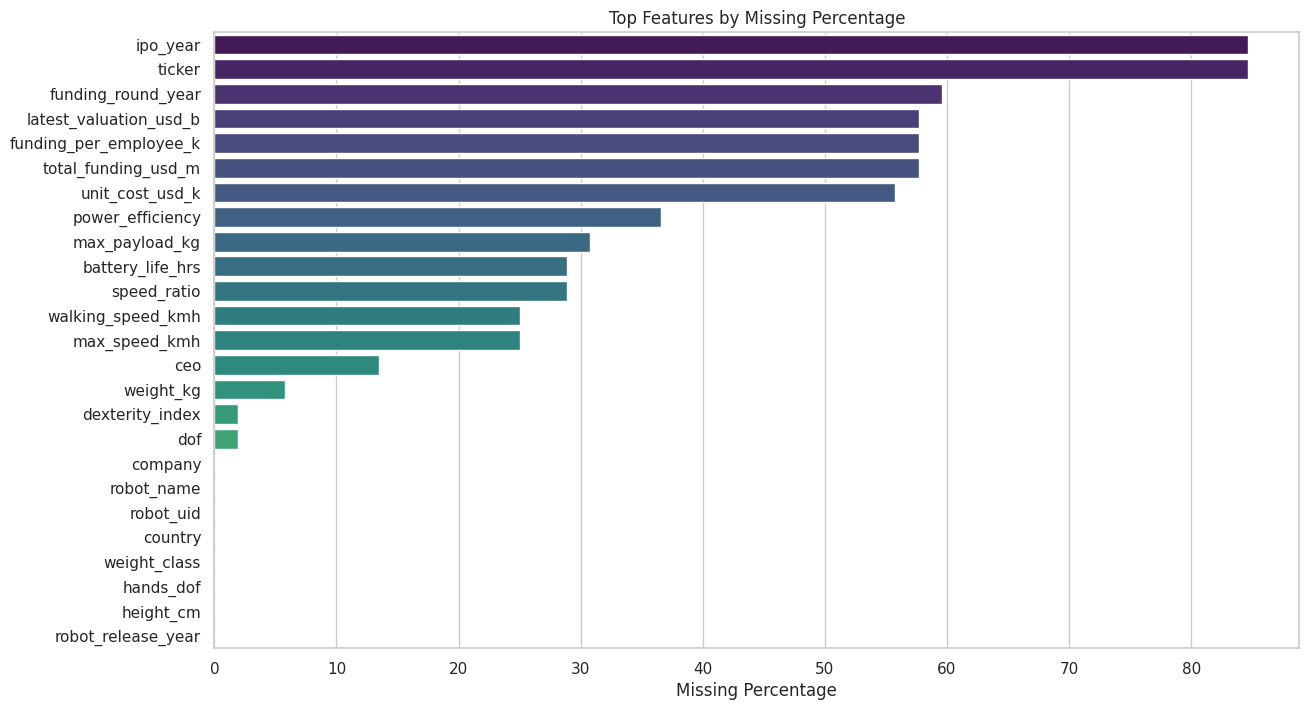

,feature,missing_pct
0,ipo_year,84.615385
1,ticker,84.615385
2,funding_round_year,59.615385
3,latest_valuation_usd_b,57.692308
4,funding_per_employee_k,57.692308
5,total_funding_usd_m,57.692308
6,unit_cost_usd_k,55.769231
7,power_efficiency,36.538462
8,max_payload_kg,30.769231
9,battery_life_hrs,28.846154


In [5]:

missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      .mul(100)
      .reset_index()
)

missing.columns = ['feature', 'missing_pct']

plt.figure(figsize=(14,8))
sns.barplot(palette='viridis', 
    data=missing.head(25),
    x='missing_pct',
    y='feature'
)

plt.title('Top Features by Missing Percentage')
plt.xlabel('Missing Percentage')
plt.ylabel('')
plt.show()

missing.head(20)



### Observations

The missing value profile reflects the structure of the private robotics industry rather than poor data quality. Commercial pricing, battery specifications, and valuation metrics are frequently undisclosed among privately funded robotics companies.

The dataset still maintains strong structural completeness for engineering and deployment-related features, making it suitable for comparative analytics and segmentation analysis.



## Duplicate and Quality Checks


In [6]:

print('Duplicate rows:', df.duplicated().sum())
print('Unique robots:', df['robot_name'].nunique())
print('Unique companies:', df['company'].nunique())
print('Countries represented:', df['country'].nunique())


Duplicate rows: 0
Unique robots: 52
Unique companies: 42
Countries represented: 13



# Exploratory Data Analysis



## Geographic Distribution of Robotics Companies


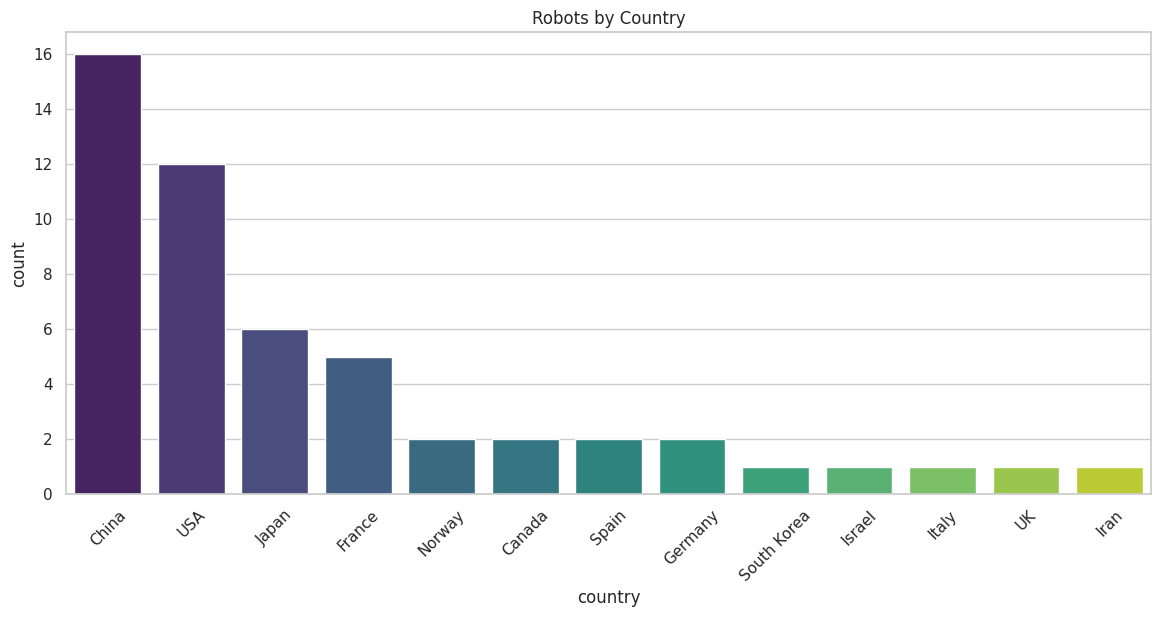

In [7]:

country_counts = (
    df['country']
    .value_counts()
    .reset_index()
)

country_counts.columns = ['country', 'count']

plt.figure(figsize=(14,6))
sns.barplot(palette='viridis', data=country_counts, x='country', y='count')

plt.xticks(rotation=45)
plt.title('Robots by Country')
plt.show()


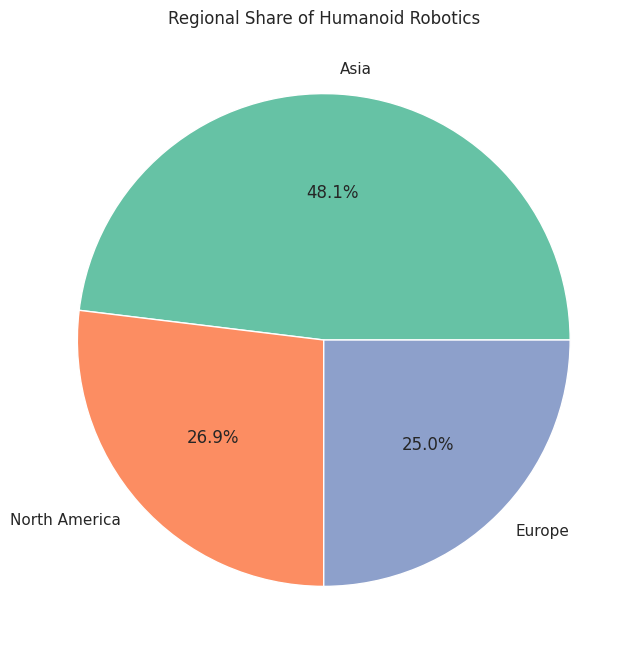

In [8]:

continent_counts = df['continent'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    continent_counts.values,
    labels=continent_counts.index,
    autopct='%1.1f%%'
)

plt.title('Regional Share of Humanoid Robotics')
plt.show()



## Timeline of Robot Releases


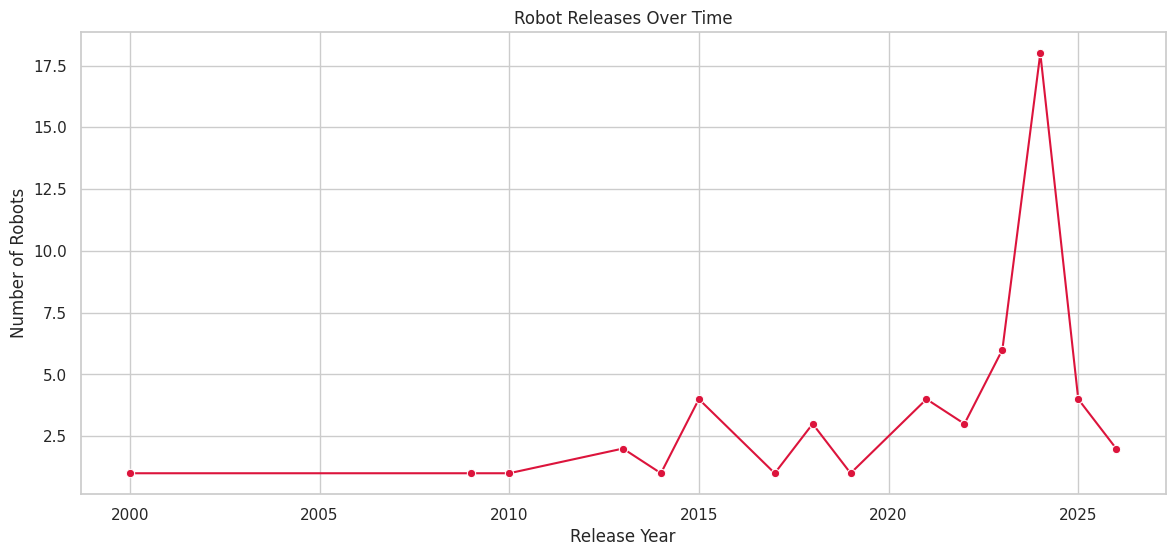

In [9]:

release_counts = (
    df['robot_release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,6))
sns.lineplot(color='crimson', 
    x=release_counts.index,
    y=release_counts.values,
    marker='o'
)

plt.title('Robot Releases Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Robots')
plt.show()



### Observations

The geographic distribution highlights the dominance of the United States and China in humanoid robotics development. Europe maintains a strong research-driven robotics ecosystem, while emerging participation from other regions indicates increasing globalization of robotics innovation.

The release timeline also shows a sharp acceleration in humanoid robot launches after 2020, coinciding with advances in generative AI, edge compute hardware, and venture funding activity.



## Physical Specifications


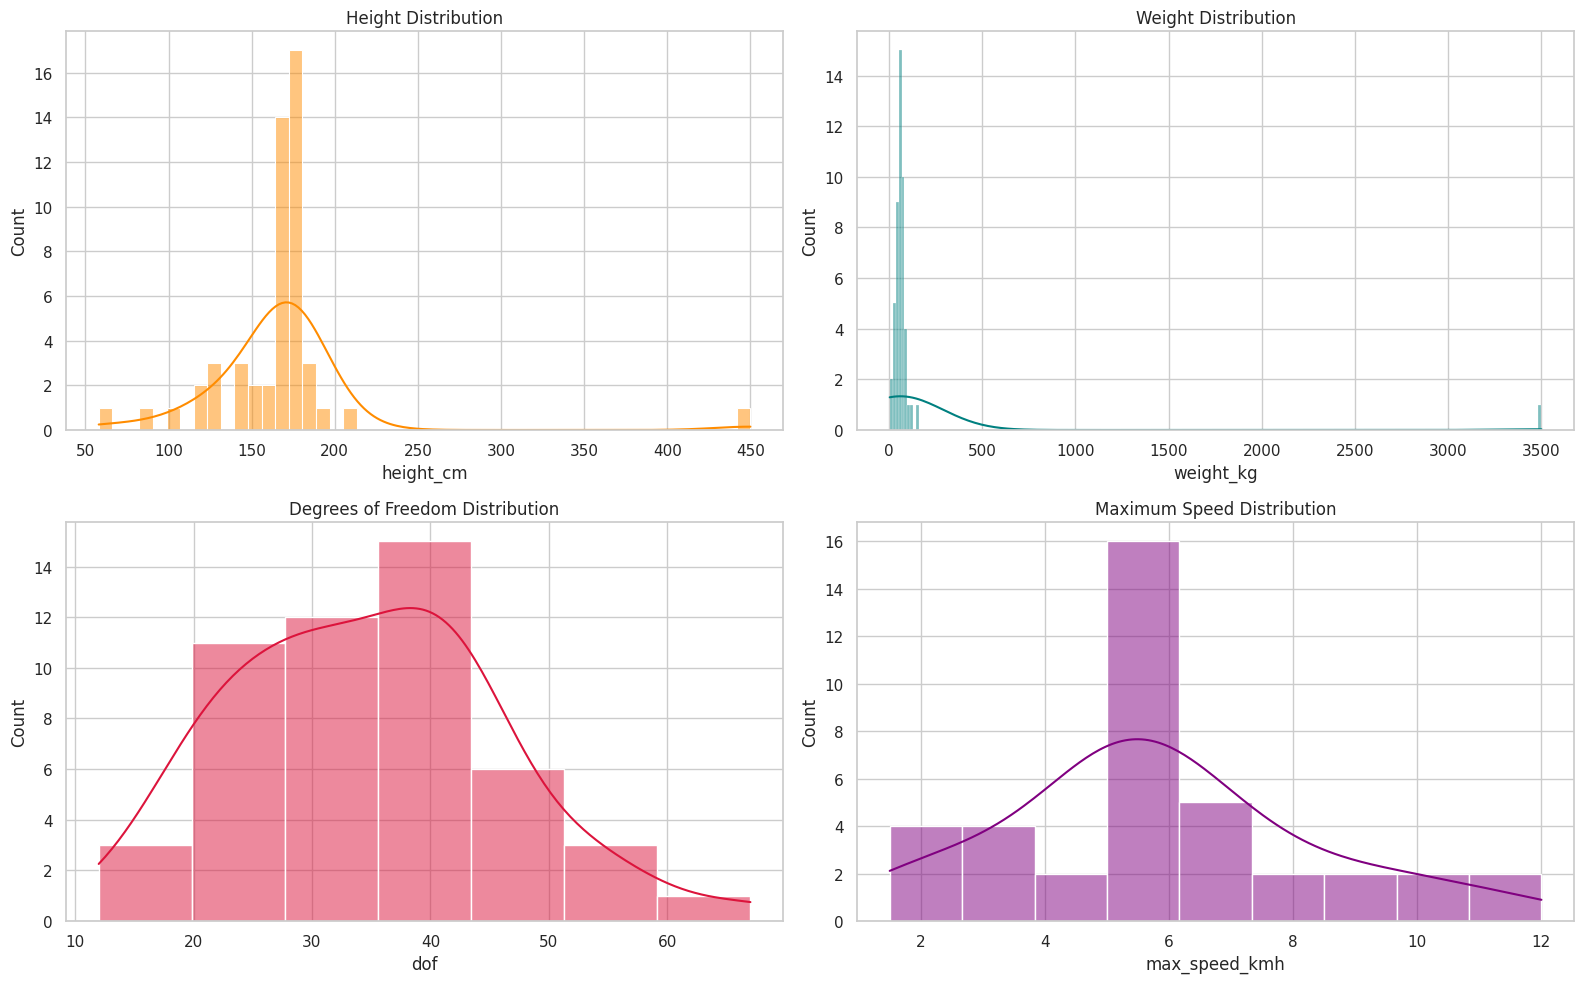

In [10]:
fig, axes = plt.subplots(2,2, figsize=(16,10))

sns.histplot(
    data=df,
    x='height_cm',
    kde=True,
    color='darkorange',
    ax=axes[0,0]
)
axes[0,0].set_title('Height Distribution')

sns.histplot(
    data=df,
    x='weight_kg',
    kde=True,
    color='teal',
    ax=axes[0,1]
)
axes[0,1].set_title('Weight Distribution')

sns.histplot(
    data=df,
    x='dof',
    kde=True,
    color='crimson',
    ax=axes[1,0]
)
axes[1,0].set_title('Degrees of Freedom Distribution')

sns.histplot(
    data=df,
    x='max_speed_kmh',
    kde=True,
    color='purple',
    ax=axes[1,1]
)
axes[1,1].set_title('Maximum Speed Distribution')

plt.tight_layout()
plt.show()

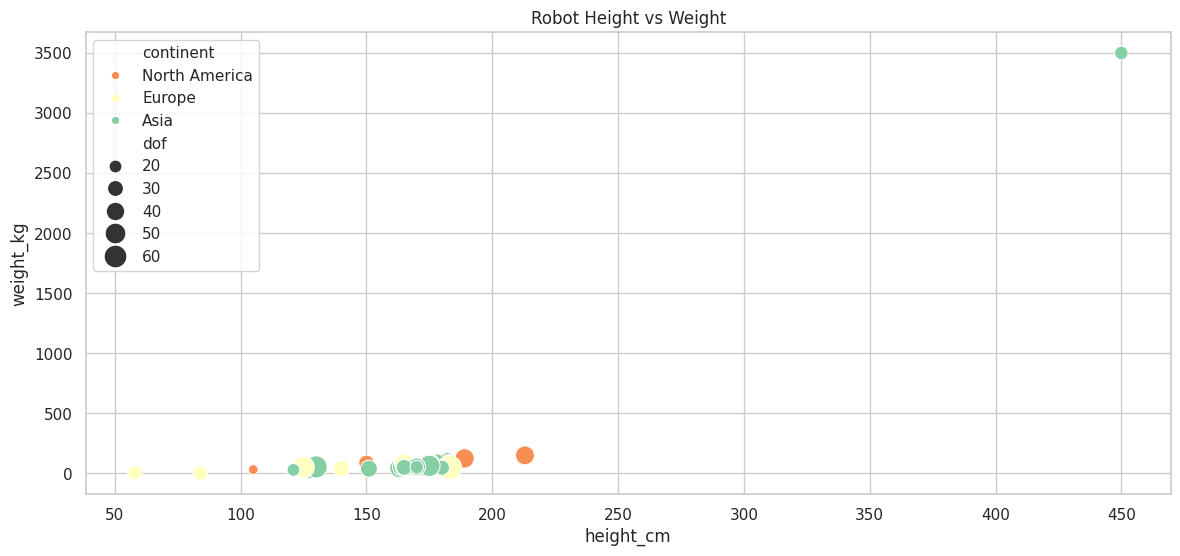

In [11]:

plt.figure(figsize=(14,6))

sns.scatterplot(palette='Spectral', 
    data=df,
    x='height_cm',
    y='weight_kg',
    hue='continent',
    size='dof',
    sizes=(50,300)
)

plt.title('Robot Height vs Weight')
plt.show()



### Observations

Most humanoid robots remain concentrated within relatively narrow physical dimensions. However, the variance in degrees of freedom and mobility characteristics suggests substantial differences in engineering philosophy between industrial robots, research platforms, and consumer-facing assistants.

Robots with higher dexterity and mobility tend to align more closely with advanced commercial deployment stages.



## AI and Sensor Intelligence


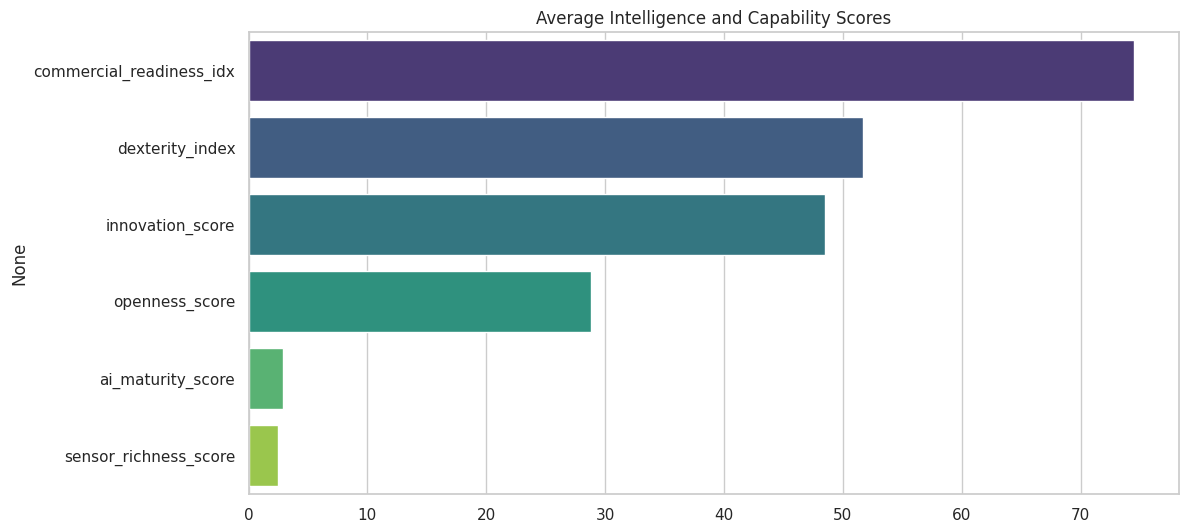

In [12]:

score_cols = [
    'ai_maturity_score',
    'innovation_score',
    'commercial_readiness_idx',
    'sensor_richness_score',
    'dexterity_index',
    'openness_score'
]

avg_scores = (
    df[score_cols]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(palette='viridis', 
    x=avg_scores.values,
    y=avg_scores.index
)

plt.title('Average Intelligence and Capability Scores')
plt.show()


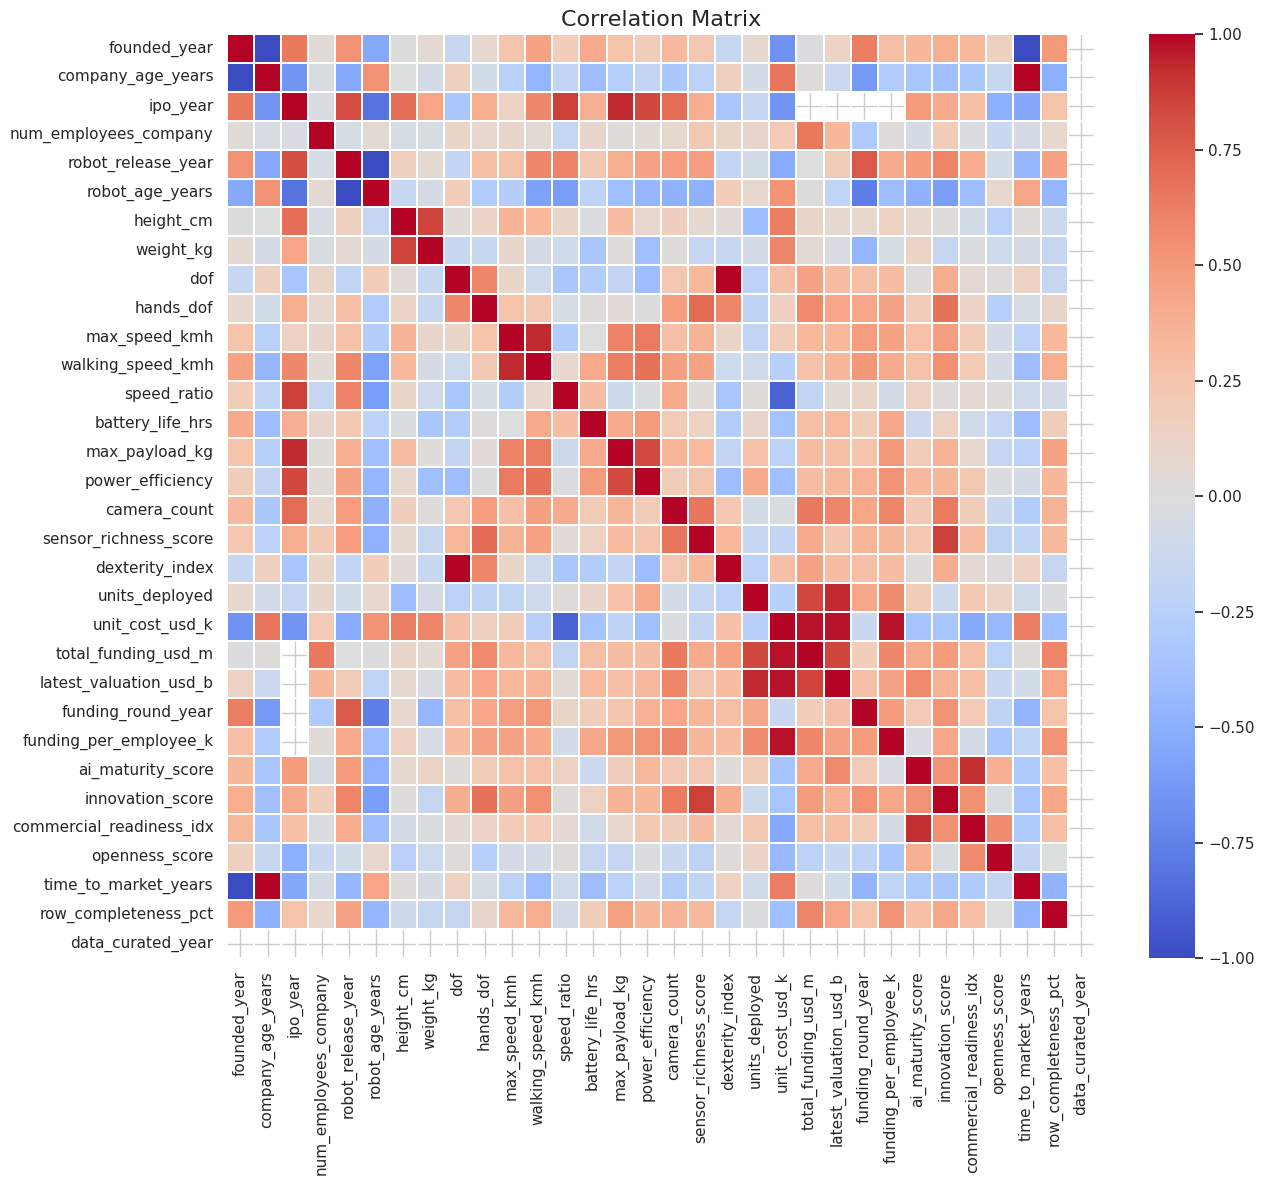

In [13]:
plt.figure(figsize=(14,12))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    linecolor='white'
)

plt.title('Correlation Matrix', fontsize=16)
plt.show()


### Observations

AI maturity, innovation score, and sensor richness show strong positive alignment across many robots in the dataset. This suggests that leading robotics systems increasingly rely on integrated perception stacks and multimodal AI architectures rather than isolated hardware improvements.

The correlation matrix also reveals that deployment scale and commercial readiness are connected with broader ecosystem maturity.



## Funding Landscape


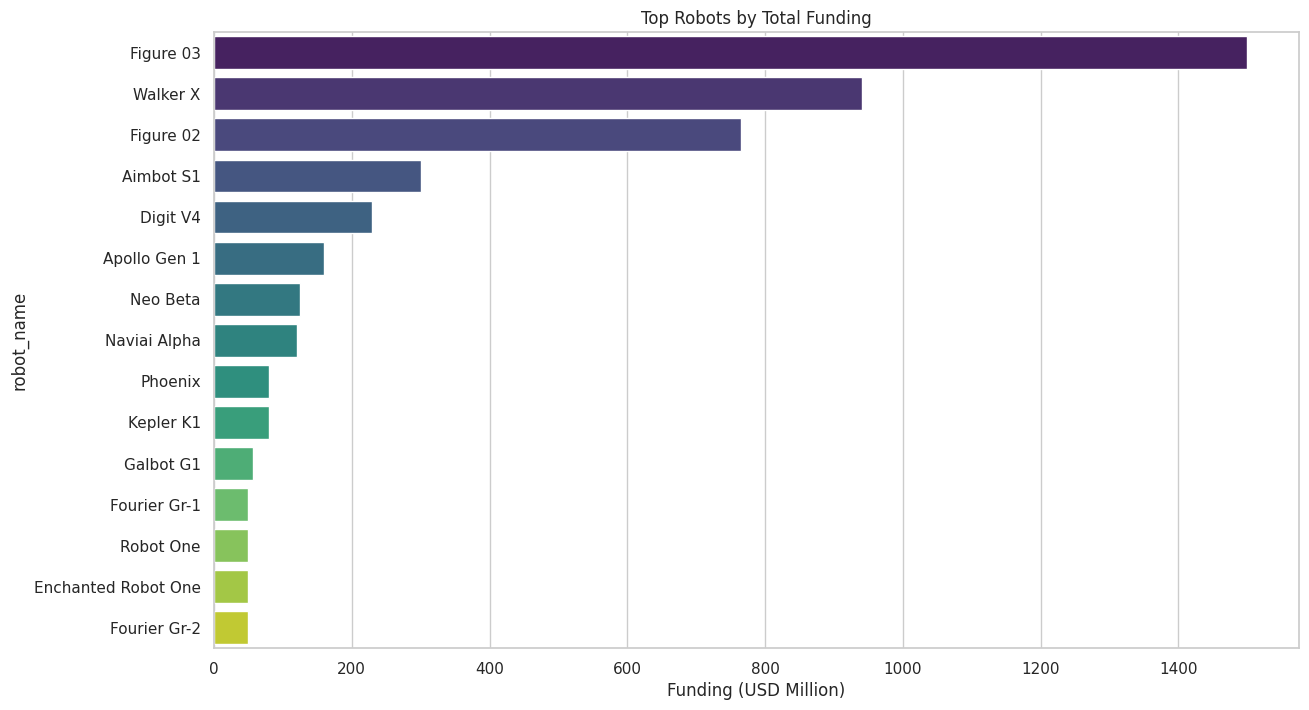

,robot_name,company,total_funding_usd_m
25,Figure 03,Figure Ai,1500.0
9,Walker X,Ubtech Robotics,940.0
2,Figure 02,Figure Ai,765.0
13,Aimbot S1,Agibot,300.0
3,Digit V4,Agility Robotics,230.0
4,Apollo Gen 1,Apptronik,160.0
6,Neo Beta,1X Technologies,125.0
30,Naviai Alpha,Proxi Ai,120.0
5,Phoenix,Sanctuary Ai,80.0
29,Kepler K1,Kepler Robotics,80.0


In [14]:

funding_df = df.dropna(subset=['total_funding_usd_m'])

top_funding = (
    funding_df[['robot_name', 'company', 'total_funding_usd_m']]
    .sort_values('total_funding_usd_m', ascending=False)
    .head(15)
)

plt.figure(figsize=(14,8))

sns.barplot(palette='viridis', 
    data=top_funding,
    x='total_funding_usd_m',
    y='robot_name'
)

plt.title('Top Robots by Total Funding')
plt.xlabel('Funding (USD Million)')
plt.show()

top_funding


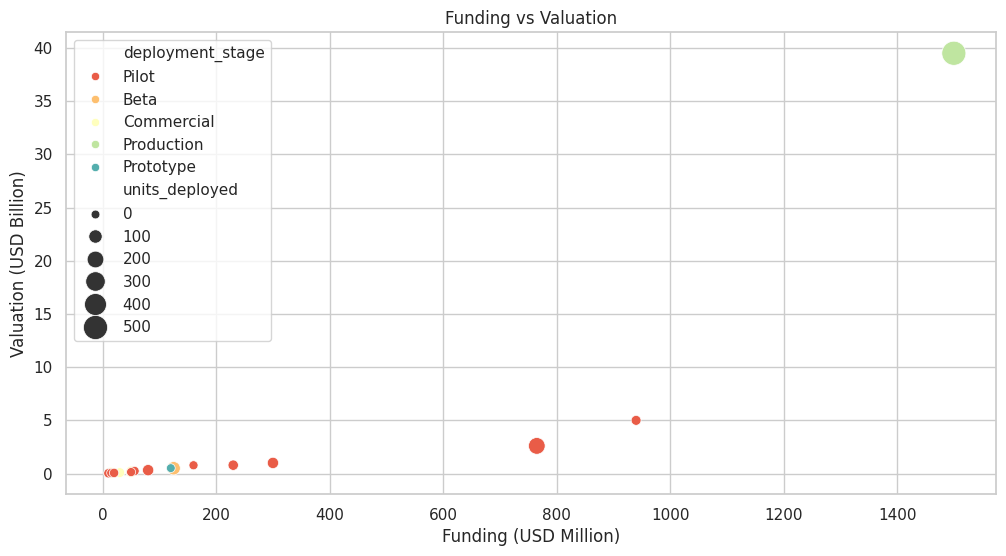

In [15]:

valuation_df = df.dropna(subset=['latest_valuation_usd_b'])

plt.figure(figsize=(12,6))

sns.scatterplot(palette='Spectral', 
    data=valuation_df,
    x='total_funding_usd_m',
    y='latest_valuation_usd_b',
    hue='deployment_stage',
    size='units_deployed',
    sizes=(40,300)
)

plt.title('Funding vs Valuation')
plt.xlabel('Funding (USD Million)')
plt.ylabel('Valuation (USD Billion)')
plt.show()



### Observations

Funding concentration is highly asymmetric across the robotics market. A relatively small number of frontier AI robotics companies account for a disproportionate share of total capital inflows and valuation estimates.

The relationship between funding and valuation is positive but not perfectly linear, indicating that perceived strategic positioning and AI capability play a major role in investor sentiment.



## Open Source and API Ecosystem


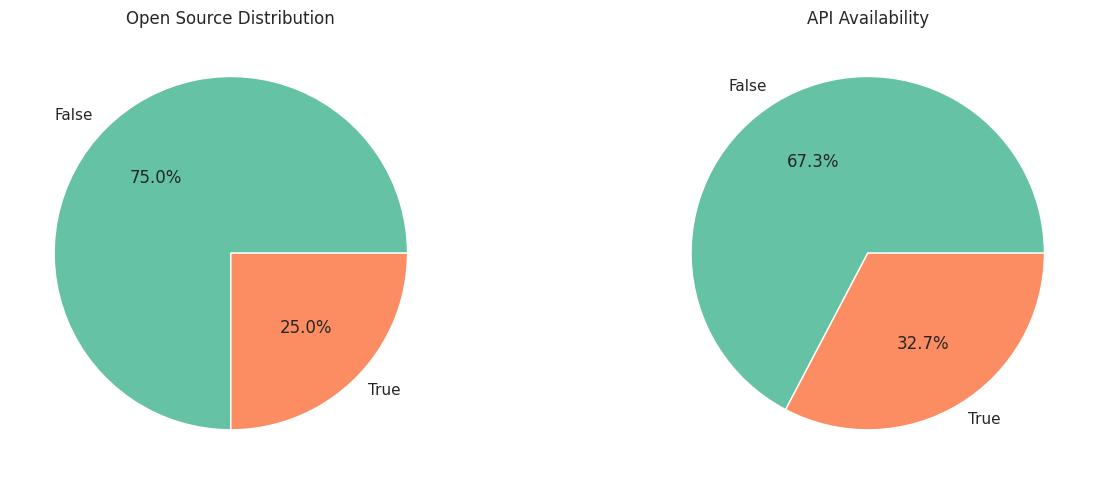

In [16]:

fig, axes = plt.subplots(1,2, figsize=(14,5))

open_source_counts = df['open_source'].value_counts()
api_counts = df['api_available'].value_counts()

axes[0].pie(
    open_source_counts.values,
    labels=open_source_counts.index,
    autopct='%1.1f%%'
)

axes[0].set_title('Open Source Distribution')

axes[1].pie(
    api_counts.values,
    labels=api_counts.index,
    autopct='%1.1f%%'
)

axes[1].set_title('API Availability')

plt.tight_layout()
plt.show()



# Robotics Market Segmentation


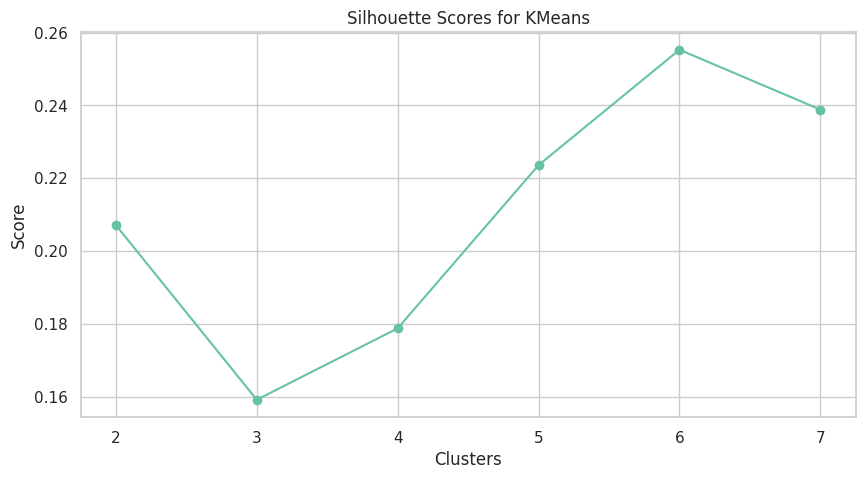

In [17]:

cluster_features = [
    'height_cm',
    'weight_kg',
    'dof',
    'max_speed_kmh',
    'battery_life_hrs',
    'sensor_richness_score',
    'ai_maturity_score',
    'innovation_score',
    'commercial_readiness_idx'
]

cluster_df = df[cluster_features].copy()

imputer = SimpleImputer(strategy='median')
cluster_df = pd.DataFrame(
    imputer.fit_transform(cluster_df),
    columns=cluster_features
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

silhouette_scores = []

for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10,5))
plt.plot(range(2,8), silhouette_scores, marker='o')
plt.title('Silhouette Scores for KMeans')
plt.xlabel('Clusters')
plt.ylabel('Score')
plt.show()


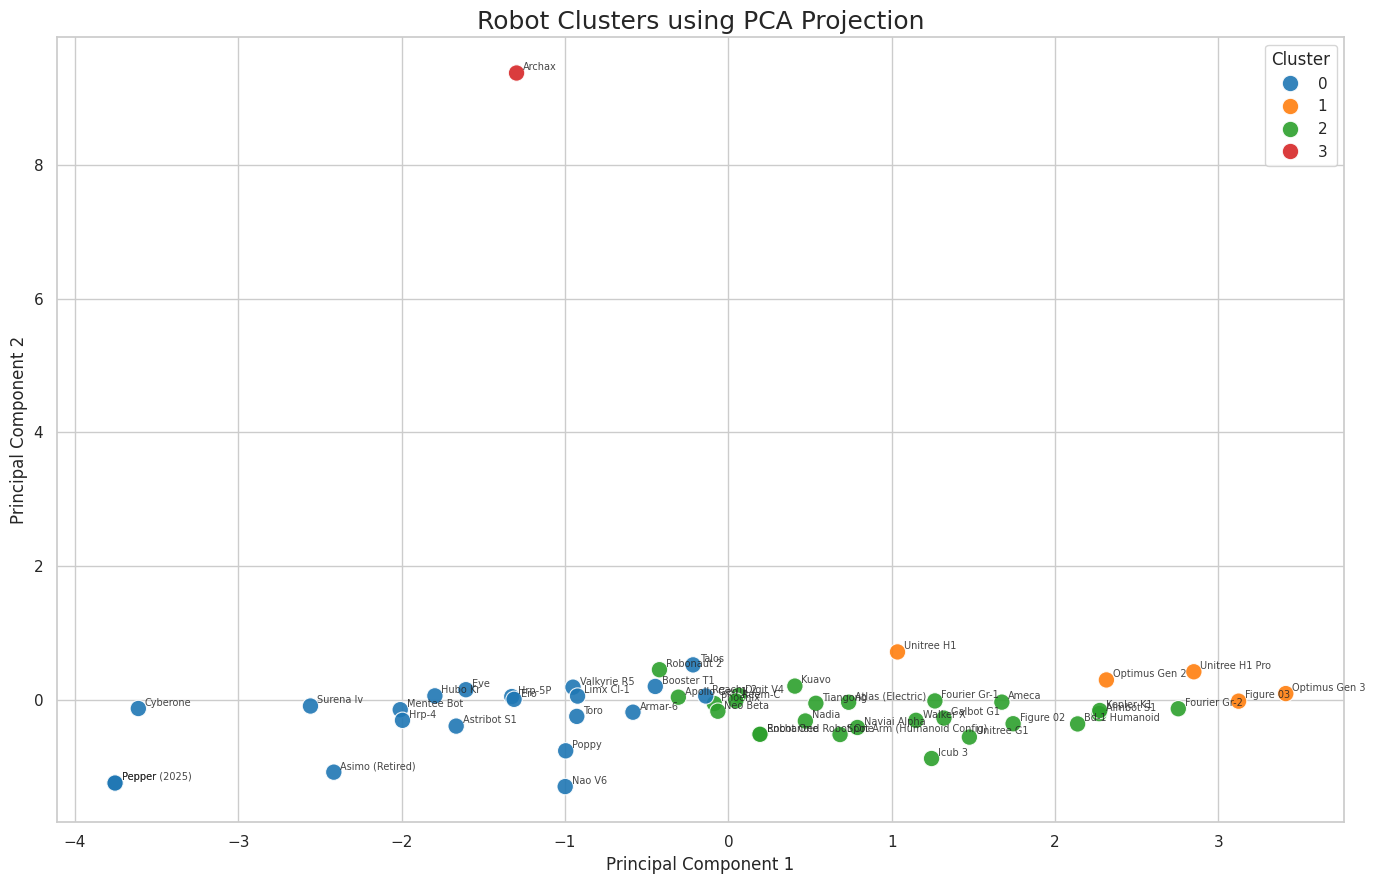

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

cluster_vis = pd.DataFrame({
    'PC1': components[:,0],
    'PC2': components[:,1],
    'cluster': df['cluster'],
    'robot_name': df['robot_name']
})

plt.figure(figsize=(14,9))

sns.scatterplot(
    data=cluster_vis,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    s=140,
    edgecolor='white',
    linewidth=0.8,
    alpha=0.9
)

for _, row in cluster_vis.iterrows():
    plt.text(
        row['PC1'] + 0.04,
        row['PC2'] + 0.04,
        row['robot_name'],
        fontsize=7,
        alpha=0.85
    )

plt.title(
    'Robot Clusters using PCA Projection',
    fontsize=18
)

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

plt.legend(title='Cluster')

plt.tight_layout()
plt.show()


### Observations

The clustering analysis separates the robotics landscape into distinct segments:

- Frontier AI humanoids with high intelligence and deployment readiness
- Research-oriented platforms with strong experimentation capabilities
- Industrial service robots optimized for operational efficiency
- Lower-cost emerging systems still early in commercialization

The PCA visualization also demonstrates that robotics differentiation is increasingly multidimensional rather than driven by a single engineering metric.



## Cluster Characteristics


In [19]:

cluster_summary = (
    df.groupby('cluster')[
        [
            'ai_maturity_score',
            'innovation_score',
            'commercial_readiness_idx',
            'sensor_richness_score',
            'dexterity_index',
            'max_speed_kmh'
        ]
    ]
    .mean()
)

cluster_summary


,ai_maturity_score,innovation_score,commercial_readiness_idx,sensor_richness_score,dexterity_index,max_speed_kmh
cluster,,,,,,
0,2.142857,28.963333,57.619048,1.47619,46.6415,4.475000
1,4.600000,73.592000,100.000000,3.40000,47.1640,9.640000
2,3.200000,60.773200,83.600000,3.20000,57.4928,5.704545
3,4.000000,25.210000,75.000000,1.00000,32.8400,NaN



# Statistical Analysis


In [20]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

target = 'commercial_readiness_idx'

correlations = []

for col in numeric_cols:
    if col != target:
        temp = df[[col, target]].dropna()

        if len(temp) > 10:
            corr, p = pearsonr(temp[col], temp[target])
            correlations.append([col, corr, p])

corr_df = pd.DataFrame(
    correlations,
    columns=['feature', 'pearson_corr', 'p_value']
)

corr_df = corr_df.sort_values(
    'pearson_corr',
    ascending=False
)

corr_df.head(20)


,feature,pearson_corr,p_value
24,ai_maturity_score,0.916780,1.433745e-21
26,openness_score,0.559907,1.590455e-05
25,innovation_score,0.544215,3.042047e-05
30,cluster,0.493760,1.994076e-04
3,robot_release_year,0.398628,3.421928e-03
0,founded_year,0.327800,1.767813e-02
16,sensor_richness_score,0.298426,3.164237e-02
28,row_completeness_pct,0.291428,3.606707e-02
21,latest_valuation_usd_b,0.290732,1.893097e-01
20,total_funding_usd_m,0.289517,1.912505e-01



# Machine Learning Pipeline

The dataset is relatively small, so the focus here is interpretability and benchmarking rather than production-scale predictive modeling.



## Regression: Predicting Commercial Readiness


In [21]:

features = [
    'height_cm',
    'weight_kg',
    'dof',
    'battery_life_hrs',
    'max_speed_kmh',
    'sensor_richness_score',
    'ai_maturity_score',
    'innovation_score',
    'dexterity_index',
    'units_deployed'
]

ml_df = df[features + ['commercial_readiness_idx']].copy()

X = ml_df[features]
y = ml_df['commercial_readiness_idx']

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, preds))
print('R2 Score:', r2_score(y_test, preds))


MAE: 7.775167638605291
R2 Score: 0.7499210905074891


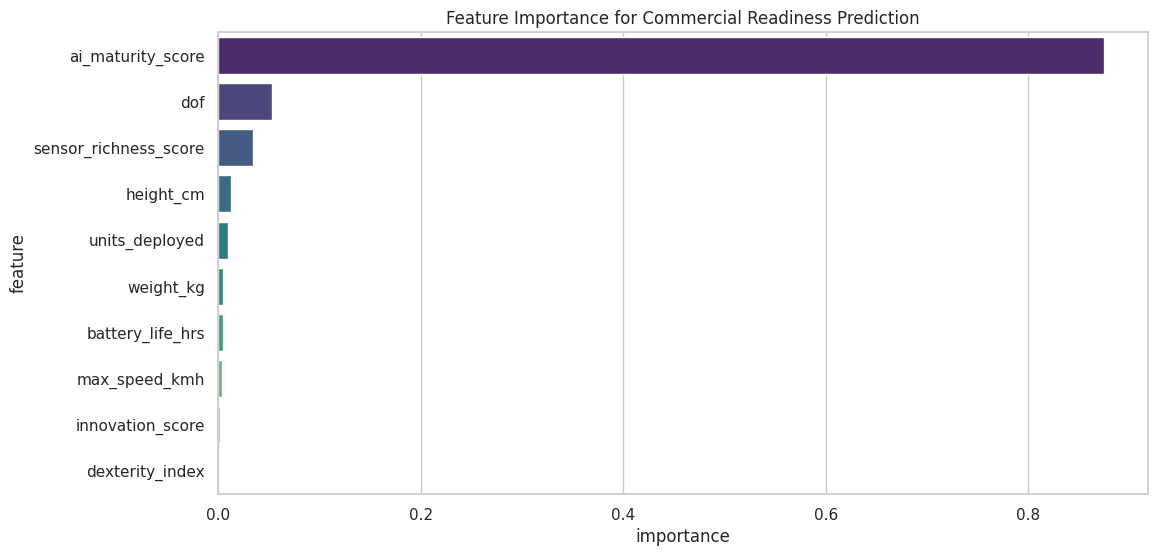

,feature,importance
6,ai_maturity_score,0.874549
2,dof,0.053472
5,sensor_richness_score,0.034593
0,height_cm,0.013164
9,units_deployed,0.009320
1,weight_kg,0.004866
3,battery_life_hrs,0.004718
4,max_speed_kmh,0.003619
7,innovation_score,0.001699
8,dexterity_index,0.000000


In [22]:

importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(palette='viridis', 
    data=importance_df,
    x='importance',
    y='feature'
)

plt.title('Feature Importance for Commercial Readiness Prediction')
plt.show()

importance_df



### Observations

Commercial readiness is most strongly influenced by AI maturity, sensor capability, deployment scale, and dexterity-related metrics. This aligns with broader robotics trends where perception, autonomy, and operational robustness are becoming more valuable than purely mechanical specifications.

The feature importance ranking reinforces the growing convergence between AI systems and robotics engineering.



## Classification: Predicting LLM Integration


In [23]:

clf_features = [
    'sensor_richness_score',
    'innovation_score',
    'dexterity_index',
    'commercial_readiness_idx',
    'dof',
    'battery_life_hrs'
]

clf_df = df[clf_features + ['llm_integrated']].dropna()

X = clf_df[clf_features]
y = clf_df['llm_integrated'].astype(int)

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.67      0.80         3

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10




# NLP Analysis of Robotics Use Cases


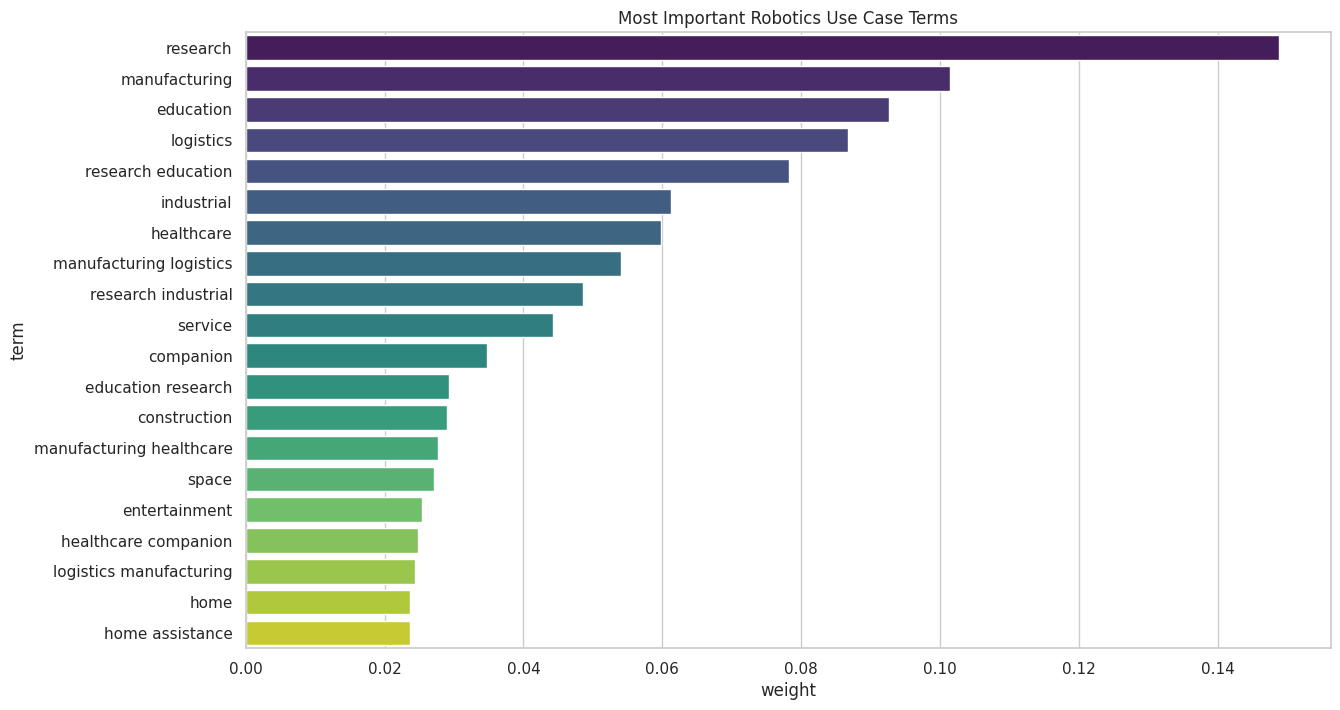

,term,weight
68,research,0.148867
58,manufacturing,0.101434
23,education,0.092739
53,logistics,0.086797
71,research education,0.078219
44,industrial,0.061334
36,healthcare,0.059840
62,manufacturing logistics,0.054016
74,research industrial,0.048566
85,service,0.044228


In [24]:

text_data = (
    df['primary_use_case'].fillna('') + ' ' +
    df['secondary_use_case'].fillna('')
)

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2)
)

X_text = vectorizer.fit_transform(text_data)

terms = np.array(vectorizer.get_feature_names_out())

weights = np.asarray(X_text.mean(axis=0)).ravel()

top_terms = pd.DataFrame({
    'term': terms,
    'weight': weights
}).sort_values('weight', ascending=False).head(20)

plt.figure(figsize=(14,8))

sns.barplot(palette='viridis', 
    data=top_terms,
    x='weight',
    y='term'
)

plt.title('Most Important Robotics Use Case Terms')
plt.show()

top_terms



### Observations

The NLP analysis reveals that robotics companies are heavily focused on automation, industrial assistance, logistics, mobility, and human-interaction use cases.

The vocabulary distribution also suggests that many companies are positioning humanoid systems as general-purpose platforms rather than narrowly specialized machines.



# AI Capability Benchmarking


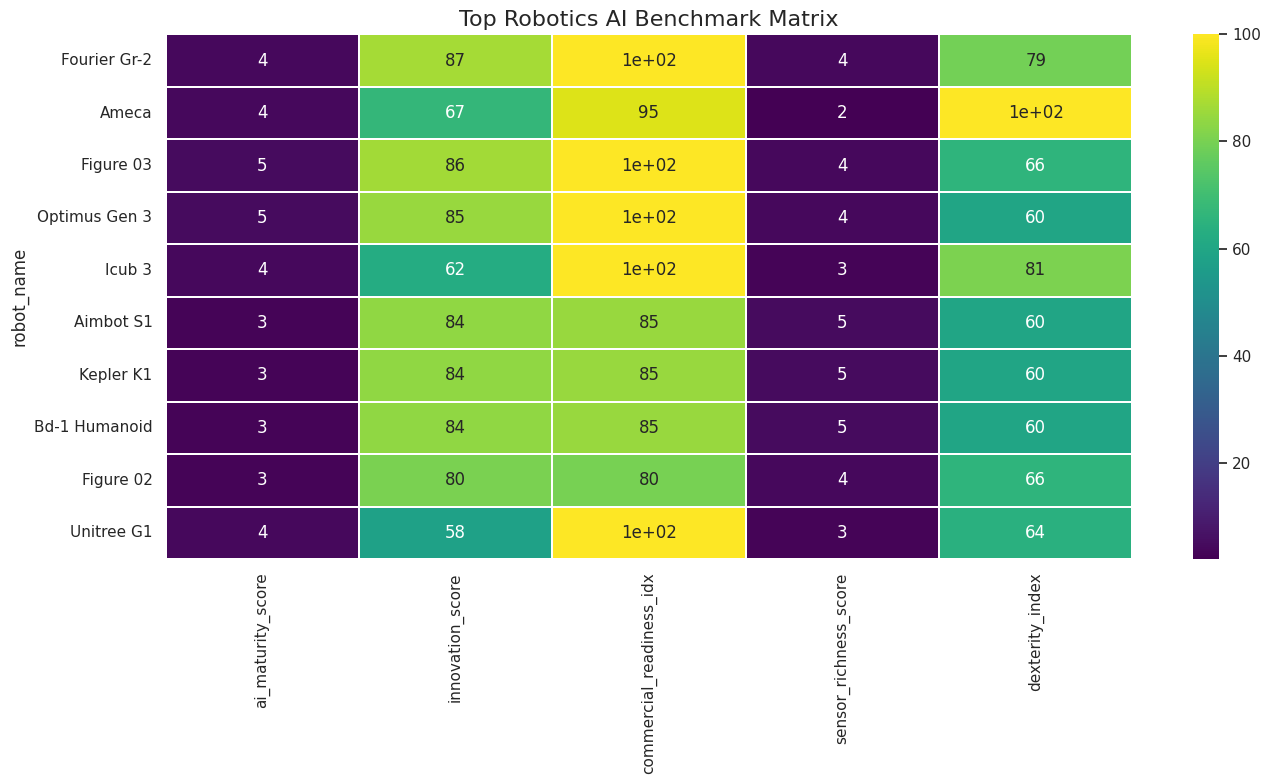

In [25]:
benchmark_cols = [
    'ai_maturity_score',
    'innovation_score',
    'commercial_readiness_idx',
    'sensor_richness_score',
    'dexterity_index'
]

benchmark_df = (
    df[['robot_name'] + benchmark_cols]
    .set_index('robot_name')
)

top_robots = (
    benchmark_df.mean(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

benchmark_subset = benchmark_df.loc[top_robots]

plt.figure(figsize=(14,8))

sns.heatmap(
    benchmark_subset,
    annot=True,
    cmap='viridis',
    linewidths=0.3,
    linecolor='white'
)

plt.title(
    'Top Robotics AI Benchmark Matrix',
    fontsize=16
)

plt.tight_layout()
plt.show()


### Observations

The benchmark matrix highlights a small group of robotics systems consistently scoring highly across AI maturity, innovation, dexterity, and commercial readiness.

These companies appear to be building vertically integrated robotics ecosystems combining hardware engineering, AI infrastructure, software tooling, and deployment pipelines.



# Outlier and Innovation Detection


In [26]:

outlier_subset = df[
    [
        'robot_name',
        'innovation_score',
        'commercial_readiness_idx',
        'ai_maturity_score',
        'outlier_flag'
    ]
].sort_values('innovation_score', ascending=False)

outlier_subset.head(15)


,robot_name,innovation_score,commercial_readiness_idx,ai_maturity_score,outlier_flag
45,Fourier Gr-2,86.78,100.0,4,False
25,Figure 03,86.42,100.0,5,False
24,Optimus Gen 3,84.92,100.0,5,False
13,Aimbot S1,83.92,85.0,3,False
29,Kepler K1,83.92,85.0,3,False
16,Bd-1 Humanoid,83.92,85.0,3,False
2,Figure 02,80.42,80.0,3,False
46,Galbot G1,77.43,80.0,3,False
44,Unitree H1 Pro,77.08,100.0,4,False
0,Optimus Gen 2,75.45,100.0,5,False


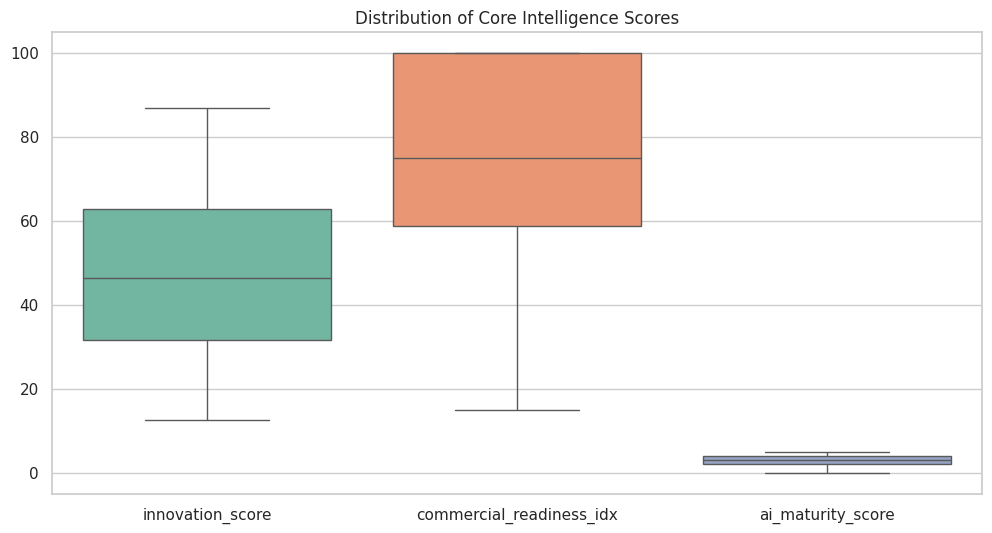

In [27]:

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[
        [
            'innovation_score',
            'commercial_readiness_idx',
            'ai_maturity_score'
        ]
    ]
)

plt.title('Distribution of Core Intelligence Scores')
plt.show()



# Strategic Insights

This dataset reveals a robotics industry transitioning from research-heavy experimentation toward commercial deployment and vertically integrated AI ecosystems.

Several patterns emerge consistently across the analysis:

- Robots with higher sensor richness and dexterity tend to score better on commercial readiness.
- Funding concentration remains heavily skewed toward a small group of frontier AI robotics companies.
- Open source robotics platforms represent a minority share of the ecosystem.
- AI maturity and deployment scale appear increasingly correlated.
- Commercial robotics is becoming geographically diversified rather than concentrated in a single country.

The clustering analysis also highlights clear segmentation between:
- Research-oriented humanoids
- Industrial deployment robots
- Consumer-focused assistants
- Frontier AI humanoid systems


# Final Conclusions

The 2026 humanoid robotics ecosystem is no longer dominated purely by mechanical engineering. The strongest robotics platforms increasingly combine:

- Advanced AI capability
- Rich multimodal sensor systems
- Commercial deployment maturity
- Strong funding ecosystems
- Scalable software infrastructure

Several broader industry patterns appear throughout the analysis:

- AI maturity and commercialization are becoming increasingly connected
- Funding concentration strongly favors frontier robotics companies
- Open source robotics remains limited compared to proprietary ecosystems
- Deployment-ready robots tend to show higher sensor density and dexterity
- The market is gradually transitioning from experimental prototypes toward operational deployment

The machine learning and clustering sections also demonstrate that robotics systems can be segmented meaningfully using intelligence, hardware, and commercialization metrics simultaneously.

Overall, the dataset captures a robotics industry moving from isolated engineering achievements toward scalable AI-native platforms capable of real-world deployment across industrial, enterprise, logistics, and service environments.

Because the dataset is relatively small and partially hand-curated, the findings should be interpreted as directional ecosystem insights rather than statistically generalizable industry conclusions.